In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Extracting '/content/drive/MyDrive/cancer cancer cancer.zip' to '/content/cancer_cancer_extracted'...
Extraction complete.

Scanning for classes and images...

Detected Classes and Sample Images:

Class: basophil (1000 images)


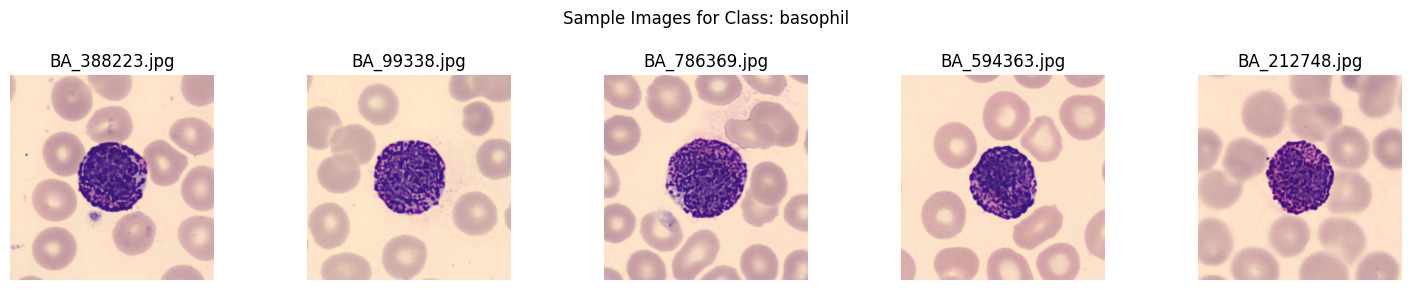


Class: myeloblast (1000 images)


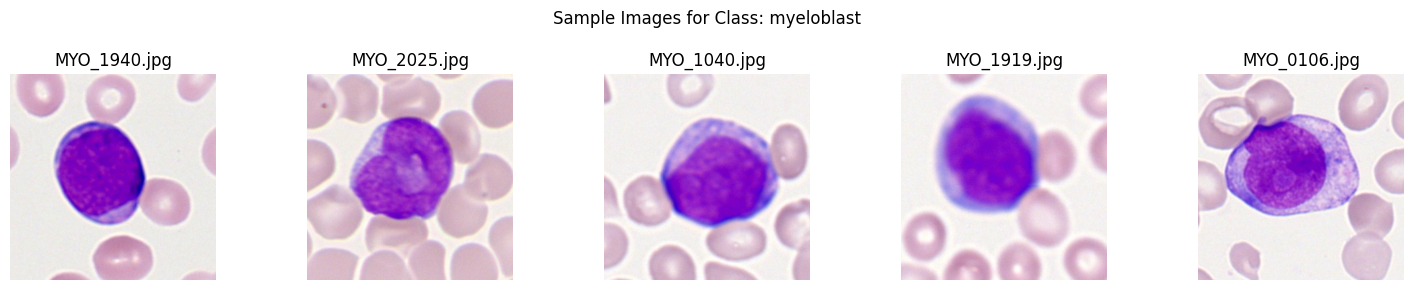


Class: monocyte (1000 images)


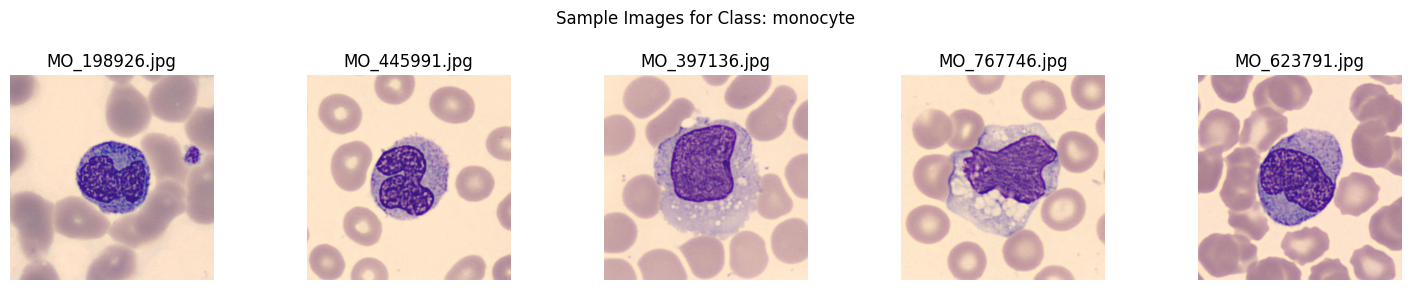


Class: seg_neutrophil (1000 images)


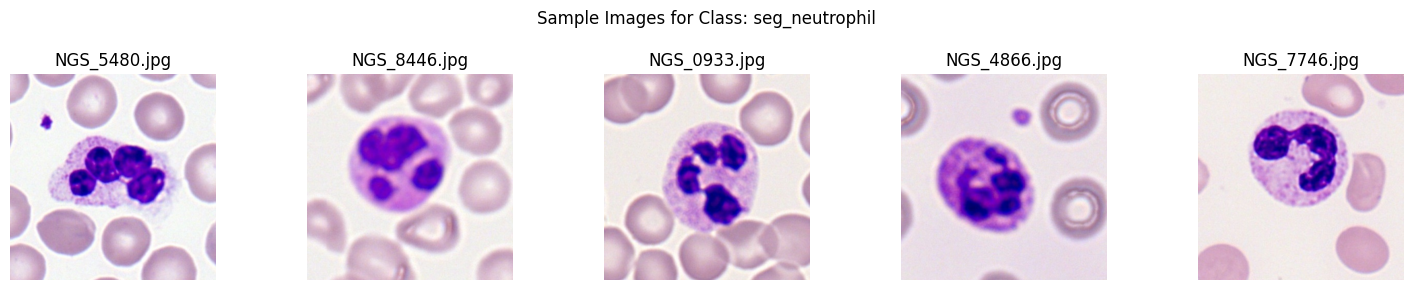


Class: erythroblast (1000 images)


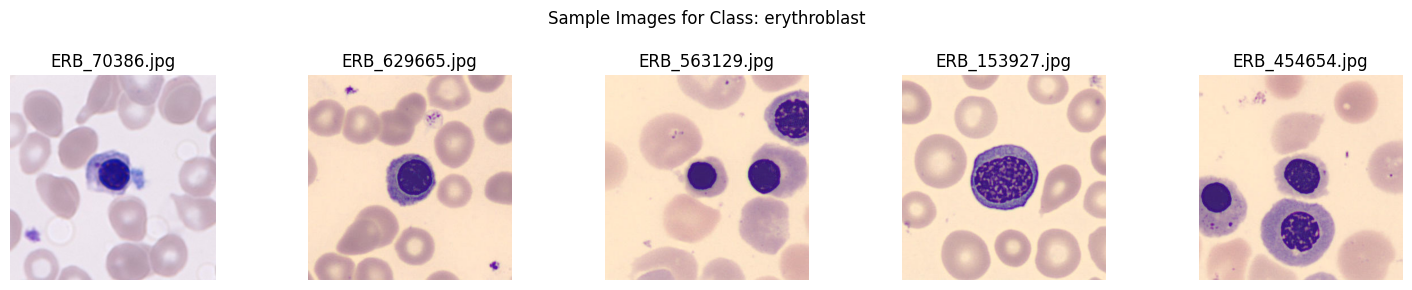

In [4]:
import zipfile
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Define the new zip file path and extraction path
zip_file_path = '/content/drive/MyDrive/cancer cancer cancer.zip'
extraction_path = '/content/cancer_cancer_extracted'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
print(f"Extracting '{zip_file_path}' to '{extraction_path}'...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
print("Extraction complete.")

# Collect images and infer classes
class_images = {}
print("\nScanning for classes and images...")
for root, dirs, files in os.walk(extraction_path):
    for dir_name in dirs:
        # Assume subdirectories under the main extracted folder are classes
        if root == extraction_path: # Direct subdirectories of the extraction_path
            class_images[dir_name] = []
    for file_name in files:
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
            # Determine the class based on the immediate parent directory
            parent_dir = os.path.basename(root)
            if parent_dir in class_images:
                class_images[parent_dir].append(os.path.join(root, file_name))

if not class_images:
    print("No classes found based on directory structure. All images might be in one folder or a different structure is used.")
    # If no classes are found this way, collect all images into a 'default' class
    all_images = []
    for root, _, files in os.walk(extraction_path):
        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
                all_images.append(os.path.join(root, file_name))
    if all_images:
        class_images['unlabeled'] = all_images

# Print class names and sample images
if class_images:
    print("\nDetected Classes and Sample Images:")
    for class_name, images in class_images.items():
        print(f"\nClass: {class_name} ({len(images)} images)")
        if images:
            # Display up to 5 random sample images from each class
            num_samples_to_display = min(5, len(images))
            sample_images_paths = random.sample(images, num_samples_to_display)

            plt.figure(figsize=(15, 3))
            for i, img_path in enumerate(sample_images_paths):
                try:
                    img = Image.open(img_path)
                    plt.subplot(1, num_samples_to_display, i + 1)
                    plt.imshow(img)
                    plt.title(os.path.basename(img_path))
                    plt.axis('off')
                except Exception as e:
                    print(f"Could not load sample image {os.path.basename(img_path)} from class {class_name}: {e}")
            plt.suptitle(f"Sample Images for Class: {class_name}")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
        else:
            print("  No images found for this class.")
else:
    print("No images or classes could be identified after extraction.")

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a DataFrame from the collected class_images
# Flatten the dictionary into a list of (image_path, class_name) tuples
image_data = []
for class_name, paths in class_images.items():
    for path in paths:
        image_data.append({'image_path': path, 'class': class_name})

df = pd.DataFrame(image_data)

# Display the first few rows of the DataFrame
print("DataFrame created successfully:")
display(df.head())
print(f"Total images in DataFrame: {len(df)}")

DataFrame created successfully:


,image_path,class
0,/content/cancer_cancer_extracted/basophil/BA_9...,basophil
1,/content/cancer_cancer_extracted/basophil/BA_8...,basophil
2,/content/cancer_cancer_extracted/basophil/BA_4...,basophil
3,/content/cancer_cancer_extracted/basophil/BA_2...,basophil
4,/content/cancer_cancer_extracted/basophil/BA_3...,basophil


Total images in DataFrame: 5000


Next, I will split the data into training and validation sets (70:30 ratio) using stratified sampling to maintain the class distribution.

In [6]:
# Split the DataFrame into training and validation sets (70:30 ratio)
# Use stratified sampling to ensure equal representation of classes in both sets
train_df, val_df = train_test_split(df, test_size=0.3, stratify=df['class'], random_state=42)

print(f"Training set size: {len(train_df)} images")
print(f"Validation set size: {len(val_df)} images")

# Display class distribution in training and validation sets
print("\nTraining set class distribution:")
display(train_df['class'].value_counts())
print("\nValidation set class distribution:")
display(val_df['class'].value_counts())

Training set size: 3500 images
Validation set size: 1500 images

Training set class distribution:


,count
class,
myeloblast,700
basophil,700
seg_neutrophil,700
erythroblast,700
monocyte,700



Validation set class distribution:


,count
class,
seg_neutrophil,300
monocyte,300
myeloblast,300
basophil,300
erythroblast,300


Now, I will set up `ImageDataGenerator` for both training (with augmentation) and validation (with EfficientNet-specific preprocessing). EfficientNet models often expect input images to be preprocessed using `tf.keras.applications.efficientnet.preprocess_input` or a similar function that scales pixel values to the range [-1, 1] or [0, 1] depending on the model's requirements. For `ImageDataGenerator`, this can be handled by setting `preprocessing_function`.

In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Define image dimensions and batch size
IMAGE_SIZE = (224, 224) # EfficientNetB2 often uses 224x224 or 260x260
BATCH_SIZE = 32

# Get the number of classes for the 'class_mode'
num_classes = len(df['class'].unique())

# Create ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # EfficientNet preprocessing
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerator for validation (no augmentation, only preprocessing)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # EfficientNet preprocessing
)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for one-hot encoding of labels
    subset='training', # Specify this is the training subset if using flow_from_dataframe with subset parameter
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    seed=42
)

print("\nData generators created successfully.")

Found 3500 validated image filenames belonging to 5 classes.
Found 1500 validated image filenames belonging to 5 classes.

Data generators created successfully.


implementaion of efficientNetB2 model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import math

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=5,            # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

model_checkpoint = ModelCheckpoint(
    'best_efficientnetb2_model.keras', # File path to save the model
    monitor='val_accuracy',          # Monitor validation accuracy
    save_best_only=True,             # Save only the best model
    mode='max',                      # Save when validation accuracy is maximized
    verbose=1
)

# Calculate steps per epoch more robustly to ensure all data is used
steps_per_epoch_train = math.ceil(train_generator.samples / BATCH_SIZE)
steps_per_epoch_val = math.ceil(val_generator.samples / BATCH_SIZE)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_train,
    epochs=20, # Start with a reasonable number of epochs, early stopping will prevent overfitting
    validation_data=val_generator,
    validation_steps=steps_per_epoch_val,
    callbacks=[early_stopping, model_checkpoint]
)

print("\nModel training complete.")

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9552 - loss: 0.1167
Epoch 1: val_accuracy improved from None to 0.97933, saving model to best_efficientnetb2_model.keras

Epoch 1: finished saving model to best_efficientnetb2_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 640s 6s/step - accuracy: 0.9546 - loss: 0.1185 - val_accuracy: 0.9793 - val_loss: 0.0589
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9600 - loss: 0.1000
Epoch 2: val_accuracy did not improve from 0.97933
110/110 ━━━━━━━━━━━━━━━━━━━━ 624s 6s/step - accuracy: 0.9629 - loss: 0.0955 - val_accuracy: 0.9700 - val_loss: 0.0879
Epoch 3/20
 57/110 ━━━━━━━━━━━━━━━━━━━━ 3:41 4s/step - accuracy: 0.9559 - loss: 0.1010

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import math

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=5,            # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

model_checkpoint = ModelCheckpoint(
    'best_efficientnetb2_model.keras', # File path to save the model
    monitor='val_accuracy',          # Monitor validation accuracy
    save_best_only=True,             # Save only the best model
    mode='max',                      # Save when validation accuracy is maximized
    verbose=1
)

# Calculate steps per epoch more robustly to ensure all data is used
steps_per_epoch_train = math.ceil(train_generator.samples / BATCH_SIZE)
steps_per_epoch_val = math.ceil(val_generator.samples / BATCH_SIZE)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_train,
    epochs=20, # Start with a reasonable number of epochs, early stopping will prevent overfitting
    validation_data=val_generator,
    validation_steps=steps_per_epoch_val,
    callbacks=[early_stopping, model_checkpoint]
)

print("\nModel training complete.")

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9430 - loss: 0.1538
Epoch 1: val_accuracy improved from None to 0.97400, saving model to best_efficientnetb2_model.keras

Epoch 1: finished saving model to best_efficientnetb2_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 622s 6s/step - accuracy: 0.9483 - loss: 0.1418 - val_accuracy: 0.9740 - val_loss: 0.0749
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9554 - loss: 0.1240
Epoch 2: val_accuracy did not improve from 0.97400
110/110 ━━━━━━━━━━━━━━━━━━━━ 591s 5s/step - accuracy: 0.9529 - loss: 0.1247 - val_accuracy: 0.9607 - val_loss: 0.0987
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9522 - loss: 0.1279
Epoch 3: val_accuracy did not improve from 0.97400
110/110 ━━━━━━━━━━━━━━━━━━━━ 589s 5s/step - accuracy: 0.9563 - loss: 0.1261 - val_accuracy: 0.9700 - val_loss: 0.0860
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9640 - loss: 0.1148
Epoch 4: val_accuracy improved from 

After training, I will plot the training history to visualize the model's performance over epochs.

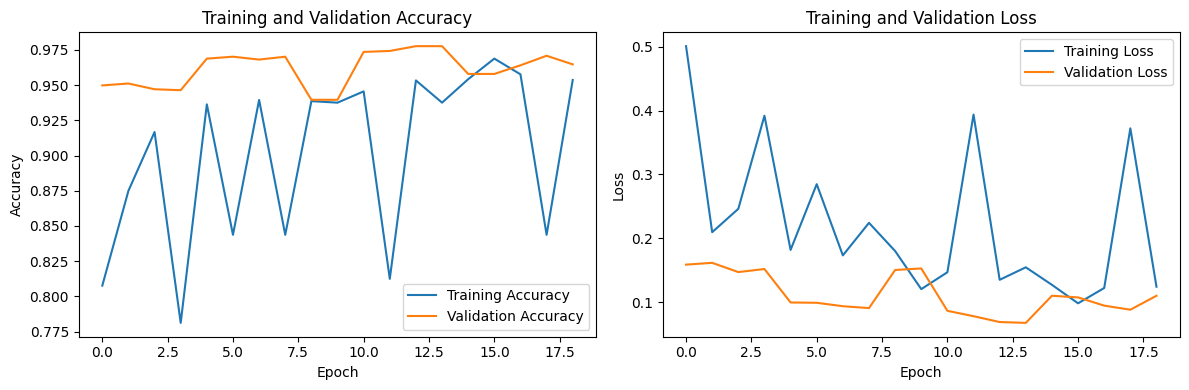

In [10]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB2

# Load the pre-trained EfficientNetB2 model
# Exclude the top (classification) layer and set input shape
base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))

# Freeze the base model layers so they are not updated during the first training phase
base_model.trainable = False

# Create a new model on top of the pre-trained base
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with softmax for multi-class classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("EfficientNetB2 model defined and compiled successfully.")
model.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB2 model defined and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 8,130,558 (31.02 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

f1score

In [14]:
# Save evaluation metrics to a text file
metrics_filename = 'efficientnetb2_evaluation_metrics.txt'
with open(metrics_filename, 'w') as f:
    f.write("Model Evaluation on Validation Set:\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Precision (weighted): {precision:.4f}\n")
    f.write(f"Recall (weighted): {recall:.4f}\n")
    f.write(f"F1-Score (weighted): {f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(val_labels, predictions_classes, target_names=class_names))

print(f"Evaluation metrics saved to {metrics_filename}")

Evaluation metrics saved to efficientnetb2_evaluation_metrics.txt


In [13]:
import numpy as np
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model('best_efficientnetb2_model.keras')

# Get true labels from the validation generator
val_labels = val_generator.classes

# Get class names from the generator
class_names = list(val_generator.class_indices.keys())

# Make predictions on the validation data
val_generator.reset() # Reset generator to ensure predictions start from the beginning
predictions_proba = best_model.predict(val_generator, steps=steps_per_epoch_val)
predictions_classes = np.argmax(predictions_proba, axis=1)

# Calculate metrics
accuracy = accuracy_score(val_labels, predictions_classes)
precision = precision_score(val_labels, predictions_classes, average='weighted')
recall = recall_score(val_labels, predictions_classes, average='weighted')
f1 = f1_score(val_labels, predictions_classes, average='weighted')

print(f"\nModel Evaluation on Validation Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# You can also print a classification report for more detailed per-class metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(val_labels, predictions_classes, target_names=class_names))

47/47 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step

Model Evaluation on Validation Set:
Accuracy: 0.9793
Precision (weighted): 0.9796
Recall (weighted): 0.9793
F1-Score (weighted): 0.9794

Classification Report:
                precision    recall  f1-score   support

      basophil       0.96      0.98      0.97       300
  erythroblast       1.00      0.97      0.98       300
      monocyte       0.96      0.96      0.96       300
    myeloblast       0.99      1.00      0.99       300
seg_neutrophil       1.00      0.99      0.99       300

      accuracy                           0.98      1500
     macro avg       0.98      0.98      0.98      1500
  weighted avg       0.98      0.98      0.98      1500



gradio


In [15]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input # EfficientNet specific preprocessing

# Load the best saved model
best_model = load_model('best_efficientnetb2_model.keras')

# Assuming class_names is already defined from previous steps
# If not, you might need to re-extract it from train_generator.class_indices
# class_names = list(train_generator.class_indices.keys())

# Define the image size used during training
# IMAGE_SIZE = (224, 224) # Assuming IMAGE_SIZE is already defined

def preprocess_image_for_gradio(image):
    # Resize the image to the target size
    image = image.resize(IMAGE_SIZE)
    # Convert PIL Image to numpy array
    image_array = np.asarray(image)
    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)
    # Apply EfficientNet preprocessing
    preprocessed_image = preprocess_input(image_array)
    return preprocessed_image

def predict_image(image):
    if image is None:
        return "Please upload an image.", {name: 0.0 for name in class_names}

    preprocessed_image = preprocess_image_for_gradio(image)

    # Make prediction
    predictions = best_model.predict(preprocessed_image)[0]

    # Get predicted class name
    predicted_class_index = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_index]

    # Format predictions for Gradio output
    confidences = {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

    return predicted_class_name, confidences

# Create Gradio Interface
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type='pil', label="Upload an Image"),
    outputs=[
        gr.Label(num_top_classes=1, label="Predicted Class"),
        gr.Label(num_top_classes=len(class_names), label="Confidences")
    ],
    title="EfficientNetB2 Cancer Cell Classification",
    description="Upload a microscopic image of a cancer cell to get its classification.",
    live=True
)

# Launch the interface
iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b89643d43aa9a5c7be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
